In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.optimize import curve_fit
from itertools import combinations
import yaml
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [8]:
bond_yields = pd.read_parquet('/Users/mma0277/Documents/Development/investment_analysis/tt-investment-analysis/data/project_work/fred_prorcessed_daily.parquet')
dependent_varaibles = [
    'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
]
bond_yields = bond_yields[dependent_varaibles]
# get the index values from the data_bonds dataframe
bond_yields_train = bond_yields[bond_yields.index.to_timestamp() < pd.Timestamp('2020-01-01')]
bond_yields_test = bond_yields[bond_yields.index.to_timestamp() >= pd.Timestamp('2020-01-01')]

print("Training set time period:", bond_yields_train.index.min(), "to", bond_yields_train.index.max())
print("Testing set time period:", bond_yields_test.index.min(), "to", bond_yields_test.index.max())
print(bond_yields_train.shape)

Training set time period: 1960-01-01 to 2019-12-31
Testing set time period: 2020-01-01 to 2024-12-31
(21915, 11)


In [19]:
# bond_yields_train = bond_yields_train.dropna()
bond_yields_train = bond_yields_train.loc['2011-01-01':]
bond_yields_train.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,4.39
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,4.44
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,4.55


In [20]:
# get the 60 day difference of the bond yields
bond_yields_diff = bond_yields_train.shift(-60) - bond_yields_train
bond_yields_diff.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
period,,,,,,,,,,,
2011-01-01,0.05,0.01,-0.02,-0.03,0.08,0.16,0.15,0.15,0.16,0.17,0.20
2011-01-02,0.05,0.01,-0.03,0.00,0.18,0.30,0.29,0.29,0.28,0.27,0.30
2011-01-03,0.00,-0.03,-0.03,-0.03,0.07,0.17,0.15,0.14,0.13,0.16,0.21
2011-01-04,-0.01,-0.02,-0.03,-0.02,0.05,0.16,0.16,0.16,0.13,0.13,0.16
2011-01-05,-0.02,-0.02,-0.03,-0.05,-0.03,0.04,0.03,0.02,-0.01,0.00,0.05


In [31]:
df_test = pd.DataFrame({'val_test': [1, 3, 3, 7, 5]})
df_test['future_val'] = df_test['val_test'].shift(-1)
df_test['val_test_shifted'] = df_test['val_test'].shift(-1) - df_test['val_test']
df_test

,val_test,future_val,val_test_shifted
0,1,3.0,2.0
1,3,3.0,0.0
2,3,7.0,4.0
3,7,5.0,-2.0
4,5,NaN,NaN


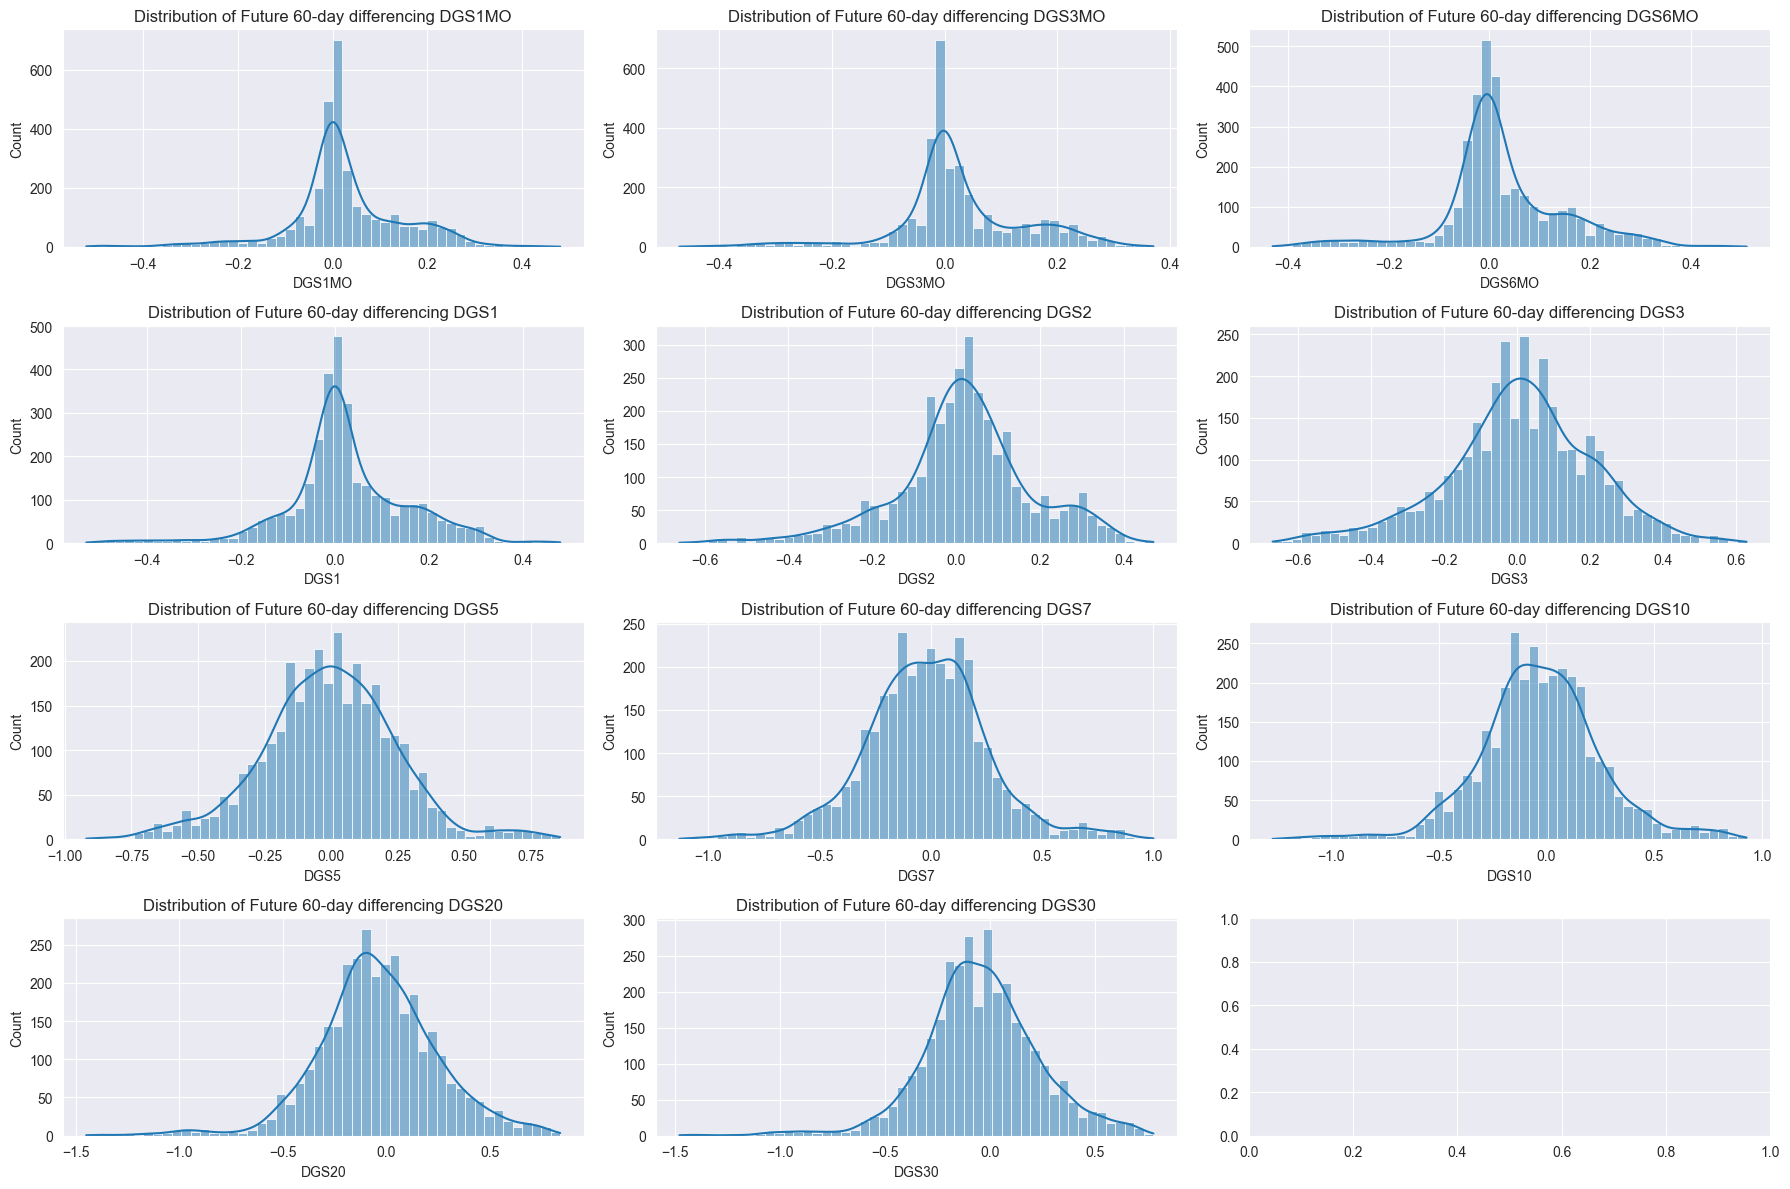

In [21]:
bond_yields_diff = bond_yields_diff.dropna()

# get the distribution of the bond yields differences
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(dependent_varaibles):
    sns.histplot(bond_yields_diff[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Future 60-day differencing {col}')
plt.tight_layout()
plt.show()

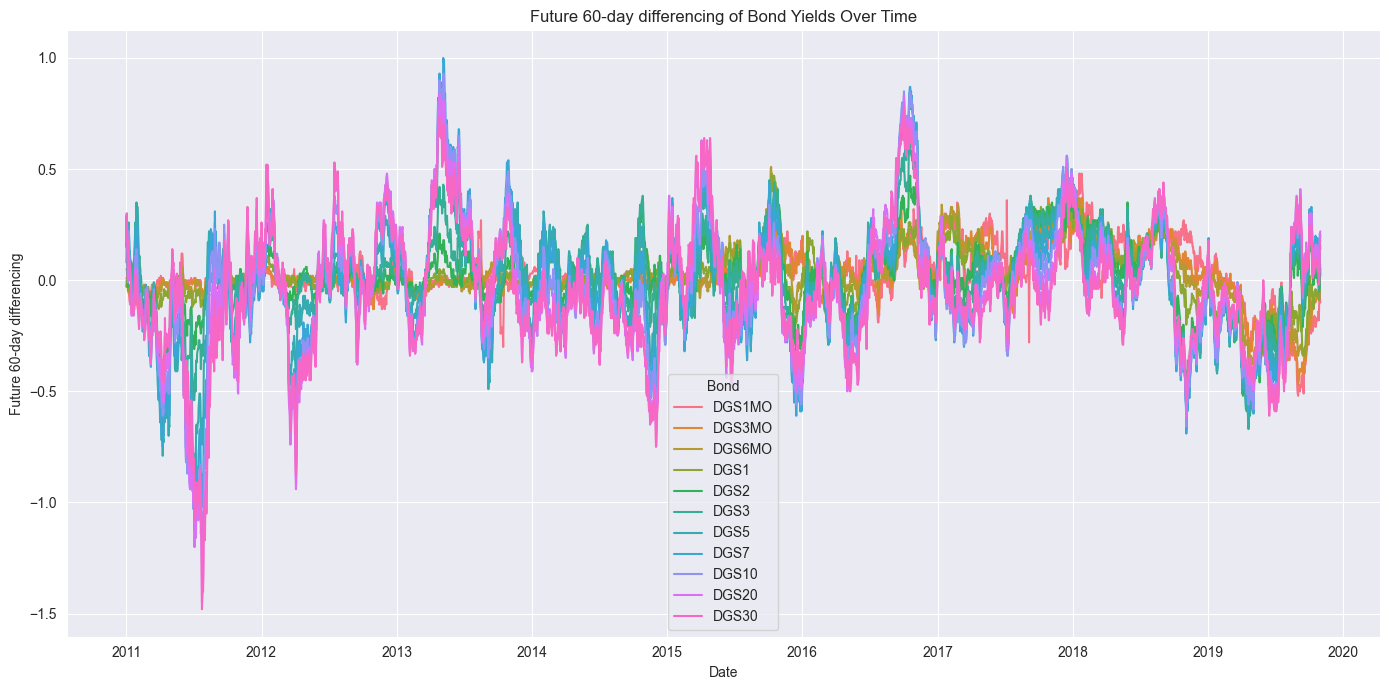

In [22]:
# melt the bond_yields_diff dataframe for easier plotting
bond_yields_diff['Date'] = bond_yields_diff.index.to_timestamp()
bond_yields_diff_melted = bond_yields_diff.melt(id_vars='Date', var_name='Bond', value_name='future_60_DayDiff')
# plot the line plot of the bond yields
plt.figure(figsize=(14, 7))
sns.lineplot(data=bond_yields_diff_melted, x='Date', y='future_60_DayDiff', hue='Bond')
plt.title('Future 60-day differencing of Bond Yields Over Time')
plt.xlabel('Date')
plt.ylabel('Future 60-day differencing')
# plt.legend(title='Bond', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
# load in the macro data
df_macro = pd.read_parquet('fred_prorcessed_daily.parquet')
df_macro = df_macro.loc['2011-01-01':'2023-12-31']
independent_cols = [col for col in df_macro.columns if col not in dependent_varaibles]
df_macro = df_macro[independent_cols]
df_macro = df_macro.drop(columns=df_macro.isna().sum()[df_macro.isna().sum() > 200].index)
df_macro = df_macro.drop(columns=['GDPNOW','DFEDTAR','M0892AUSM156SNBR'])
print("Number of rows with NaN:", df_macro.isna().any(axis=1).sum())


Number of rows with NaN: 0


In [24]:
numeric_check = df_macro.iloc[:, 0:].apply(lambda col: pd.api.types.is_numeric_dtype(col))
non_numeric_cols = numeric_check[~numeric_check].index.tolist()
if len(non_numeric_cols) == 0: print("All columns from the second column onwards are numeric.")
else: print("The following columns are not numeric:", non_numeric_cols)

All columns from the second column onwards are numeric.


In [27]:
# create a function that will scale each column down so the max value is single digits
def scale_to_single_digits(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Scale each column down so the max value is single digits
    """
    # iterate through each column
    for col in cols:
        max_val = df[col].max()
        if pd.isna(max_val) or max_val == 0:
            continue
        scale_factor = 10 ** (len(str(int(max_val))) - 1)
        df.loc[:, col] = df[col] / scale_factor
        # df[col].describe()
    return df

# data_bonds2 = scale_to_single_digits(df=data_bonds, cols=independent_variables)
# rem
df_macro2 = scale_to_single_digits(df=df_macro, cols=df_macro.columns)
df_macro2.describe()

,EXPINF1YR,REAINTRATREARAT1YE,DTB1YR,T10YIE,EXPINF10YR,HQMCB10YR,REAINTRATREARAT10Y,T10Y2Y,T10Y3M,T10YFF,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
count,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,...,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000
mean,1.856343,-0.575499,1.143433,2.037228,1.795246,3.758048,0.569535,0.995343,1.284490,1.303732,...,0.952822,0.952317,0.820380,3.230750,2.589644,4.820257,1.435151,0.192445,0.219909,2.356339
std,0.663221,1.783221,1.441847,0.360732,0.270777,0.861781,0.541788,0.895918,1.130903,1.063893,...,0.363213,0.340402,0.132198,0.790188,0.135355,2.302364,0.161262,0.700236,0.217855,0.624802
min,-0.218790,-3.966425,0.040000,0.500000,1.158350,2.010000,-0.407134,-1.080000,-1.890000,-1.710000,...,0.460000,0.480000,0.500000,2.100000,1.671740,1.215000,1.128000,0.000002,-0.812000,1.620819
25%,1.505249,-1.595162,0.130000,1.770000,1.612740,3.260000,0.163998,0.290000,0.637500,0.800000,...,0.620000,0.640000,0.723000,2.700000,2.497370,1.564750,1.348000,0.000006,0.173000,1.845109
50%,1.734398,-1.075625,0.340000,2.100000,1.758975,3.730000,0.536151,1.030000,1.490000,1.450000,...,0.860000,0.860000,0.825000,3.000000,2.626465,5.631000,1.460000,0.000010,0.221000,2.214973
75%,2.123089,0.027137,1.770000,2.300000,1.958324,4.230000,0.836172,1.620000,2.030000,1.990000,...,1.260000,1.260000,0.938000,3.400000,2.685965,6.295000,1.552000,0.000960,0.264000,2.654689
max,4.226713,8.005603,5.220000,3.020000,2.454670,6.110000,2.094329,2.910000,3.600000,3.590000,...,1.750000,1.690000,1.014000,5.400000,2.854520,8.205000,1.724000,4.171327,1.056000,3.607142


In [32]:
df_test = pd.DataFrame({'val_test': [1, 3, 3, 7, 5]})
df_test['future_val'] = df_test['val_test'].shift(1)
df_test['val_test_shifted'] = df_test['val_test'] - df_test['val_test'].shift(1)
df_test

,val_test,future_val,val_test_shifted
0,1,NaN,NaN
1,3,1.0,2.0
2,3,3.0,0.0
3,7,3.0,4.0
4,5,7.0,-2.0


In [34]:
df_macro2_diff = pd.DataFrame(index=df_macro2.index)
for col in df_macro2.columns:
    df_macro2_diff.loc[:, f'{col}'] = df_macro2[col] - df_macro2[col].shift(1)

print(f"Shape of df_macro2_diff: {df_macro2_diff.shape}")

df_macro2_diff.describe()


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_32984/1852869918.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_macro2_diff.loc[:, f'{col}'] = df_macro2[col] - df_macro2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_32984/1852869918.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_macro2_diff.loc[:, f'{col}'] = df_macro2[col] - df_macro2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_32984/1852869918.py:3: PerformanceWarning: DataFrame is highly fragme

Shape of df_macro2_diff: (4748, 483)


,EXPINF1YR,REAINTRATREARAT1YE,DTB1YR,T10YIE,EXPINF10YR,HQMCB10YR,REAINTRATREARAT10Y,T10Y2Y,T10Y3M,T10YFF,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
count,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,...,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4747.000000,4.747000e+03,4747.000000,4747.000000
mean,0.000274,0.000576,0.000902,-0.000029,0.000066,0.000017,0.000172,-0.000640,-0.000990,-0.000973,...,-0.000255,-0.000223,-0.000009,-0.000063,0.000050,-0.001397,-0.000075,6.646598e-09,-0.000032,0.000402
std,0.080150,0.210013,0.026398,0.025935,0.018762,0.035701,0.035337,0.031543,0.044417,0.053781,...,0.018910,0.017406,0.007659,0.059691,0.015036,0.055552,0.004303,6.083392e-02,0.016756,0.003391
min,-1.297190,-2.900893,-0.550000,-0.320000,-0.407918,-0.620000,-0.615722,-0.170000,-0.320000,-0.850000,...,-0.230000,-0.180000,-0.173000,-1.400000,-0.591700,-3.727000,-0.262000,-4.133440e+00,-0.273000,-0.013060
25%,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000,-0.010000,-0.020000,-0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.010000,0.010000,0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
max,1.108054,6.857697,0.320000,0.250000,0.309116,0.700000,0.639434,0.420000,0.340000,0.640000,...,0.940000,0.990000,0.084000,1.200000,0.371300,0.072000,0.049000,2.056320e-01,0.275000,0.064055


In [35]:
# merge the bond_yields_diff and df_macro2_diff dataframes on the index
data_merged = bond_yields_diff.merge(df_macro2_diff, left_index=True, right_index=True, how='left')
print(f"Shape of data_merged: {data_merged.shape}")
print(f"shape of bond_yields_diff: {bond_yields_diff.shape}")
data_merged.head()

Shape of data_merged: (3227, 495)
shape of bond_yields_diff: (3227, 12)


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.05,0.01,-0.02,-0.03,0.08,0.16,0.15,0.15,0.16,0.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.05,0.01,-0.03,0.00,0.18,0.30,0.29,0.29,0.28,0.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.00,-0.03,-0.03,-0.03,0.07,0.17,0.15,0.14,0.13,0.16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-04,-0.01,-0.02,-0.03,-0.02,0.05,0.16,0.16,0.16,0.13,0.13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-05,-0.02,-0.02,-0.03,-0.05,-0.03,0.04,0.03,0.02,-0.01,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
df_macro2_diff.head()

,EXPINF1YR,REAINTRATREARAT1YE,DTB1YR,T10YIE,EXPINF10YR,HQMCB10YR,REAINTRATREARAT10Y,T10Y2Y,T10Y3M,T10YFF,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.0,0.0,0.00,0.01,0.0,0.0,0.0,0.06,0.03,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-04,0.0,0.0,-0.01,0.04,0.0,0.0,0.0,-0.02,0.01,0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-05,0.0,0.0,0.03,0.07,0.0,0.0,0.0,0.06,0.14,0.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# persist the merged dataframe
data_merged.to_parquet('bond_yields_60day_diff_macro_1day_diff.parquet', index=True)